<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong> Sep 7, 2025 <strong>Author:</strong> Adnan Alaref
</div>

# **Positional Encoding**

Unlike recurrent or convolutional models, the Transformer processes all tokens **in parallel**, so it does not inherently know the order of the tokens.

For example:

> **"I love cats"** ≠ **"Cats love I"**

Therefore, we need to inject **positional information** into the token representations.

The input to the Transformer is typically:

$$
\mathbf{X} = \mathbf{E} + \mathbf{P}
$$

where:

- $\mathbf{E}$ — token embeddings
- $\mathbf{P}$ — positional encodings
- $\mathbf{X}$ — position-aware representations

---

## Why should positional encoding be bounded?

Since position is added directly to the embedding, extremely large positional values could dominate the semantic information:

$$
\mathbf{x}_i = \mathbf{e}_i + \mathbf{p}_i
$$

Thus, positional encodings should provide positional information **without overwhelming the token embedding**.

This motivates the use of **bounded functions**, such as sine and cosine.

---

## What should a good positional encoding provide?

A useful positional encoding should:

1. Represent the **absolute position** of each token.
2. Allow the model to infer **relative positions** between tokens.
3. Preserve the semantic information of the token embeddings.
4. Ideally, generalize to sequence lengths beyond those seen during training.

Several approaches have been proposed:

- **Sinusoidal Positional Encoding**
- **Learnable Positional Embeddings**
- **Relative Positional Encoding**
- **Rotary Positional Encoding (RoPE)**

The first approach we'll examine is **Sinusoidal Positional Encoding**.

---

## **Sinusoidal Positional Encoding**

The Transformer processes tokens in **parallel**, so self-attention alone does not know the order of tokens. Positional Encoding injects this information into the token embeddings.

The original Transformer uses **Sinusoidal Positional Encoding**, where each position is represented using sine and cosine functions with different frequencies.

For position `pos` and dimension `i`:

$$
PE_{(pos,2i)}
=
\sin\left(
\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}
\right)
$$

$$
PE_{(pos,2i+1)}
=
\cos\left(
\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}
\right)
$$

where:

- `pos` = token position
- `i` = dimension index
- $d_{\text{model}}$ = embedding dimension

The positional encoding is added directly to the token embedding:

$$
\mathbf{x}_{pos}
=
\mathbf{e}_{pos}
+
\mathbf{PE}_{pos}
$$

### Why Sine and Cosine?

Different dimensions use different frequencies:

$$
\text{frequency}
\propto
\frac{1}
{10000^{\frac{2i}{d_{\text{model}}}}}
$$

Therefore:

- **Low dimensions** → higher frequency → change rapidly with position.
- **High dimensions** → lower frequency → change slowly with position.

Because:

$$
-1 \leq \sin(x),\cos(x) \leq 1
$$

the positional values remain **bounded**, preventing them from overwhelming the token embeddings.

### Absolute → Relative Position

Each position has a unique combination of sine and cosine values, providing **absolute positional information**.

At the same time, shifting the position produces a predictable change in these values, which allows the model to learn **relative positional relationships** between tokens.

Thus, sinusoidal encoding provides a simple way to represent both **where a token is** and **how far tokens are from each other**.

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 1: Import Library.</div>

In [1]:
import math
import torch
import numpy as np
import torch.nn as nn
from typing import List
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)

In [ ]:
# rm -rf /kaggle/working/{*,.[!.]*,..?*}

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2: Sinusoidal Positional Encoding Implementations.</div>

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2.1: Naive Sinusoidal Positional Encoding Implementation.</div>

**Two equivalent implementations are possible:**

- **Loop over sine/cosine pairs:** `i = 0, 2, 4, ...`
- **Loop over all dimensions:** use `(i // 2)` so each sine/cosine pair **shares the same frequency.**

In [2]:
def positional_encoding_pairwise(seq_len: int, d_model: int)-> np.ndarray:
  assert d_model % 2 == 0,\
    "d_model must be even to pair sine and cosine dimensions as in the original Transformer paper."

  PE = np.zeros((seq_len, d_model))


  for pos in range(seq_len):
    for i in range(0, d_model, 2):
      angle = pos / (10000 ** (i / d_model))

      PE[pos][i] = np.sin(angle)
      PE[pos][i+1] = np.cos(angle)

  return PE

# Example
PE = positional_encoding_pairwise(seq_len=5, d_model=6)

print(PE)
print(PE.shape)

[[ 0.          1.          0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.04639922  0.99892298  0.00215443  0.99999768]
 [ 0.90929743 -0.41614684  0.0926985   0.99569422  0.00430886  0.99999072]
 [ 0.14112001 -0.9899925   0.1387981   0.9903207   0.00646326  0.99997911]
 [-0.7568025  -0.65364362  0.18459872  0.98281398  0.00861763  0.99996287]]
(5, 6)


In [3]:
def positional_encoding_by_dimension(seq_len: int, d_model: int)-> np.ndarray:
  assert d_model % 2 == 0,\
    "d_model must be even to pair sine and cosine dimensions as in the original Transformer paper."

  PE = np.zeros((seq_len, d_model))


  for pos in range(seq_len):
    for i in range(d_model):
      angle = pos / (10000 ** (2 * (i // 2) / d_model))

      if i %2==0:
        PE[pos][i] = np.sin(angle)
      else:
        PE[pos][i] = np.cos(angle)

  return PE

# Example
PE = positional_encoding_by_dimension(seq_len=5, d_model=6)

print(PE)
print(PE.shape)

[[ 0.          1.          0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.04639922  0.99892298  0.00215443  0.99999768]
 [ 0.90929743 -0.41614684  0.0926985   0.99569422  0.00430886  0.99999072]
 [ 0.14112001 -0.9899925   0.1387981   0.9903207   0.00646326  0.99997911]
 [-0.7568025  -0.65364362  0.18459872  0.98281398  0.00861763  0.99996287]]
(5, 6)


## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2.2: Numerically Stable Sinusoidal Positional Encoding.</div>

                                                               << Numerical Stability >>

The direct implementation computes:

$$
\frac{1}{10000^{i/d_{\text{model}}}}
$$

This requires computing the power $10000^{i/d_{\text{model}}}$ first, which can lead to numerical issues for large values.

Using:

$$
a^b = e^{b\ln(a)}
$$

we can rewrite it as:

$$
\frac{1}{10000^{i/d_{\text{model}}}}
=
e^{-\frac{i}{d_{\text{model}}}\ln(10000)}
$$

Therefore, we use:

```python
div_term = torch.exp(
    -(i / embed_dim) * np.log(10000)
)
```

This computes the same value while avoiding the direct computation of the power.

**Key idea:** Compute the exponent in the **log domain**, then apply `exp()`.


In [4]:
def sinusoidal_positional_encoding_stable(seq_len: int, d_model: int)-> np.ndarray:
  assert d_model % 2 == 0,\
    "d_model must be even to pair sine and cosine dimensions as in the original Transformer paper."

  PE = np.zeros((seq_len, d_model))

  for pos in range(seq_len):
    for i in range(0, d_model, 2):

      # Numerically stable equivalent of:
      # 1 / (10000 ** (i / d_model))
      div_term = np.exp((-i / d_model) * np.log(10000))

      angle = pos * div_term

      PE[pos, i] = np.sin(angle)
      PE[pos, i+1] = np.cos(angle)

  return PE

# Example
PE = sinusoidal_positional_encoding_stable(seq_len=5, d_model=6)

print(PE)
print(PE.shape)

[[ 0.          1.          0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.04639922  0.99892298  0.00215443  0.99999768]
 [ 0.90929743 -0.41614684  0.0926985   0.99569422  0.00430886  0.99999072]
 [ 0.14112001 -0.9899925   0.1387981   0.9903207   0.00646326  0.99997911]
 [-0.7568025  -0.65364362  0.18459872  0.98281398  0.00861763  0.99996287]]
(5, 6)


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 3: Vectorized Sinusoidal Positional Encoding Implementation.</div>

In [9]:
class PositionalEncoding(nn.Module):
  def __init__(self, max_seq_len: int, embed_dim: int) -> None:
    super().__init__()

    assert embed_dim % 2 == 0,\
    "d_model must be even to pair sine and cosine dimensions as in the original Transformer paper."

    PE = torch.zeros((max_seq_len, embed_dim))

    pos = torch.arange(max_seq_len)[:,None]
    i = torch.arange(0, embed_dim, 2)

    div_term = torch.exp(-(i / embed_dim) * math.log(10000.0))

    angle = pos * div_term

    PE[:,0::2] = torch.sin(angle)
    PE[:,1::2] = torch.cos(angle)

    # Register pe as a buffer that is not a parameter, but should be in the state_dict.
    self.register_buffer("PE",PE)


  def forward(self, x: torch.Tensor )-> torch.Tensor:
    # Get size of x, e.g. 60, then add 60 x 512 elment wise
    return x + self.PE[:x.shape[1],:]

# Example
batch_size = 1  # Batch size
embed_dim = 6  # Embedding size
max_len = 100  # Maximum sequence length
seq_len = 5 # Sequence length of the input

# Example tensor representing embeddings of shape (seq_len, batch_size, d_model)
example_input = torch.randn(batch_size, seq_len, embed_dim)

# Create the PositionalEncoding module and apply it
positional_encoder = PositionalEncoding(max_len, embed_dim)
encoded_input = positional_encoder(example_input)

print("Shape of encoded input:", encoded_input.shape)
# The shape of encoded_input will be the same as example_input,
# but with positional information added.
print(f"Encoded input:\n{encoded_input}")

Shape of encoded input: torch.Size([1, 5, 6])
Encoded input:
tensor([[[-0.8083,  0.2070,  0.2458,  1.4267,  0.4700,  0.2429],
         [ 1.4823,  0.8952, -0.1245,  2.4341, -0.2102,  1.0069],
         [ 0.1969, -1.0578,  0.7233, -0.1055, -0.2348,  0.8128],
         [-0.1918, -1.9179,  0.7872, -0.0700,  0.2864,  1.4874],
         [-1.6192, -1.3654, -0.5829,  1.9335, -0.8771,  1.5925]]])


In [10]:
print(f"Positional Information Values:\n{positional_encoder.PE[:5]}")

Positional Information Values:
tensor([[ 0.0000,  1.0000,  0.0000,  1.0000,  0.0000,  1.0000],
        [ 0.8415,  0.5403,  0.0464,  0.9989,  0.0022,  1.0000],
        [ 0.9093, -0.4161,  0.0927,  0.9957,  0.0043,  1.0000],
        [ 0.1411, -0.9900,  0.1388,  0.9903,  0.0065,  1.0000],
        [-0.7568, -0.6536,  0.1846,  0.9828,  0.0086,  1.0000]])


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4: Visual Analysis of Sinusoidal Positional Encoding.</div>

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4.1: Visualizing Frequency Across Dimensions.</div>

**This visualization demonstrates the important property:**

> **Lower dimensions oscillate faster, while higher dimensions oscillate more slowly.**

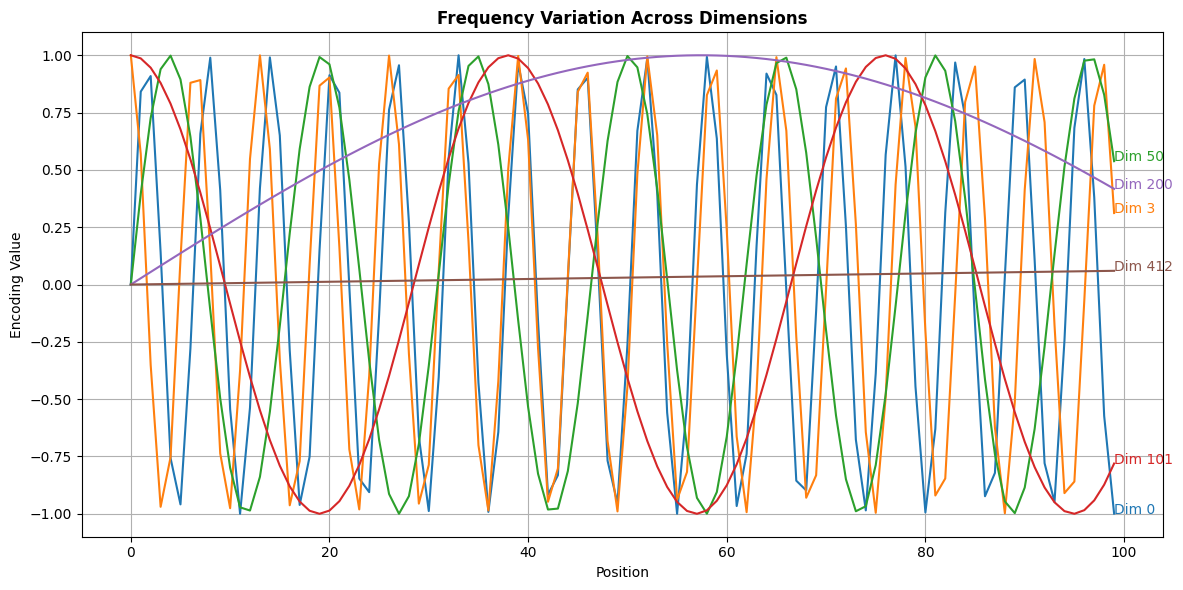

In [12]:
embed_dim = 512
max_seq_len = 100
positions = np.arange(max_seq_len)

position_encoder = PositionalEncoding(max_seq_len, embed_dim)
pos_encodings = position_encoder.PE.numpy()

dimensions = [0, 3, 50, 101, 200, 412]

plt.figure(figsize=(12,6), dpi=100)
for d in dimensions:
  # line = plt.plot(...)[0] or direct
  line, = plt.plot(
    positions,
    pos_encodings[:, d],
    label=f"Dim {d}"
  )

  plt.text(
    positions[-1],
    pos_encodings[:,d][-1],
    f"Dim {d}",
    color = line.get_color()
  )

plt.title("Frequency Variation Across Dimensions", fontsize=12, fontweight="bold")
plt.xlabel("Position")
plt.ylabel("Encoding Value")
# plt.legend(loc="best")
plt.grid(True)

plt.tight_layout()
plt.show()

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4.2: Visualizing Frequency and Base Effects in Positional Encoding.</div>

In [13]:
def positional_encoding_variant_base(max_seq_len: int,
                                     d_model: int,
                                     base: int)-> np.ndarray:
  assert d_model % 2 == 0,\
    "d_model must be even to pair sine and cosine dimensions as in the original Transformer paper."

  PE = np.zeros((max_seq_len, d_model))

  for pos in range(max_seq_len):
    for i in range(0, d_model, 2):
      div_term = np.exp((-i / d_model) * np.log(base))

      angle = pos * div_term

      PE[pos, i] = np.sin(angle)
      PE[pos, i+1] = np.cos(angle)

  return PE

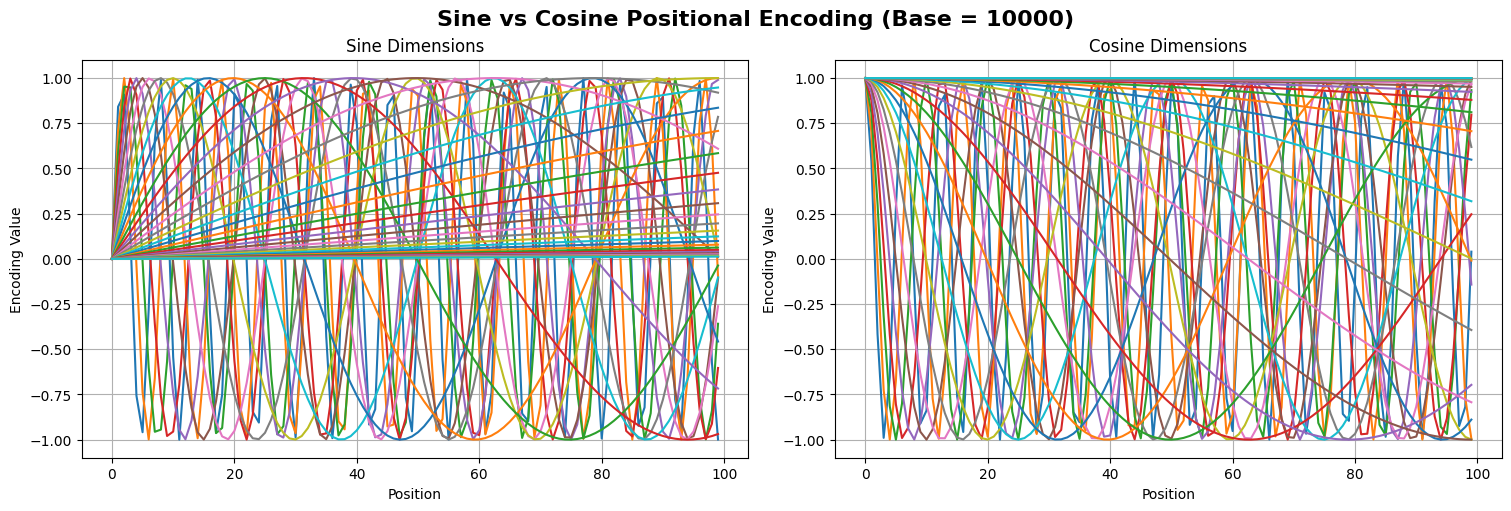

In [14]:
def plot_sin_cos(max_seq_len: int, d_model: int, base: int = 10000):

    pe_matrix = positional_encoding_variant_base(
        max_seq_len,
        d_model,
        base
    )

    positions = np.arange(max_seq_len)

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(15, 5),
        layout="constrained"
    )

    # Sine dimensions ─────────────────────────
    for d in range(0, d_model, 2):
      axes[0].plot(
          positions,
          pe_matrix[:, d],
          label=f"Dim {d}"
      )

    axes[0].set_title("Sine Dimensions")
    axes[0].set_xlabel("Position")
    axes[0].set_ylabel("Encoding Value")
    axes[0].set_ylim(-1.1, 1.1)
    axes[0].grid(True)

    # Cosine dimensions ────────────────────────
    for d in range(1, d_model, 2):
      axes[1].plot(
          positions,
          pe_matrix[:, d],
          label=f"Dim {d}"
      )

    axes[1].set_title("Cosine Dimensions")
    axes[1].set_xlabel("Position")
    axes[1].set_ylabel("Encoding Value")
    axes[1].set_ylim(-1.1, 1.1)
    axes[1].grid(True)

    fig.suptitle(
        f"Sine vs Cosine Positional Encoding (Base = {base})",
        fontsize=16,
        fontweight="bold"
    )

    plt.savefig(
        "/kaggle/working/plot_sin_cos.png",
        dpi=100,
        bbox_inches="tight"
    )
    
    plt.show()


plot_sin_cos(
  max_seq_len=100,
  d_model=80,
  base=10000 # Explore 1, 10, 100, 1_000, 10_000
)

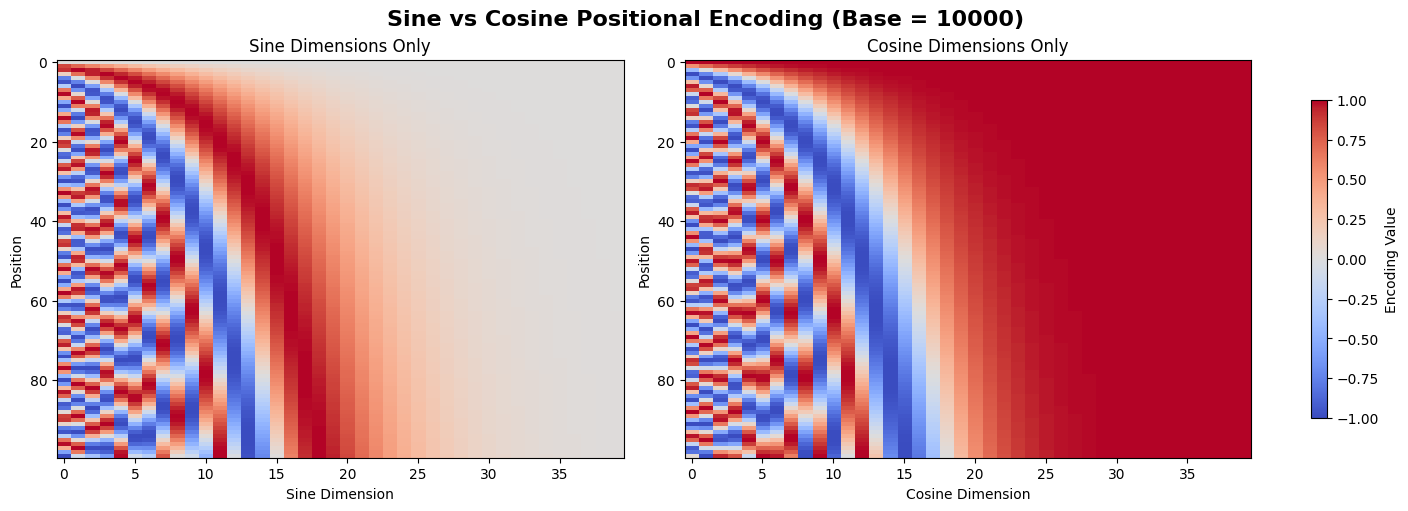

In [15]:
def plot_sin_cos_heatmaps(
    max_seq_len: int,
    d_model: int,
    base: int = 10000
):
    pe_matrix = positional_encoding_variant_base(
        max_seq_len,
        d_model,
        base
    )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 5),
        layout="constrained"
    )

    # Sine dimensions: 0, 2, 4, ...
    sine_matrix = pe_matrix[:, 0::2]

    # Cosine dimensions: 1, 3, 5, ...
    cosine_matrix = pe_matrix[:, 1::2]

    # Sine heatmap
    im1 = axes[0].imshow(
        sine_matrix,
        cmap="coolwarm",
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    axes[0].set_title("Sine Dimensions Only")
    axes[0].set_xlabel("Sine Dimension")
    axes[0].set_ylabel("Position")

    # Cosine heatmap
    im2 = axes[1].imshow(
        cosine_matrix,
        cmap="coolwarm",
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    axes[1].set_title("Cosine Dimensions Only")
    axes[1].set_xlabel("Cosine Dimension")
    axes[1].set_ylabel("Position")

    # One shared colorbar
    fig.colorbar(
        im1,
        ax=axes,
        location="right",
        label="Encoding Value",
        shrink=0.8
    )

    fig.suptitle(
        f"Sine vs Cosine Positional Encoding (Base = {base})",
        fontsize=16,
        fontweight="bold"
    )

    plt.savefig(
        "/kaggle/working/sin_cos_heatmaps.png",
        dpi=100,
        bbox_inches="tight"
    )
    
    plt.show()


plot_sin_cos_heatmaps(
    max_seq_len=100,
    d_model=80,
    base=10_000
)

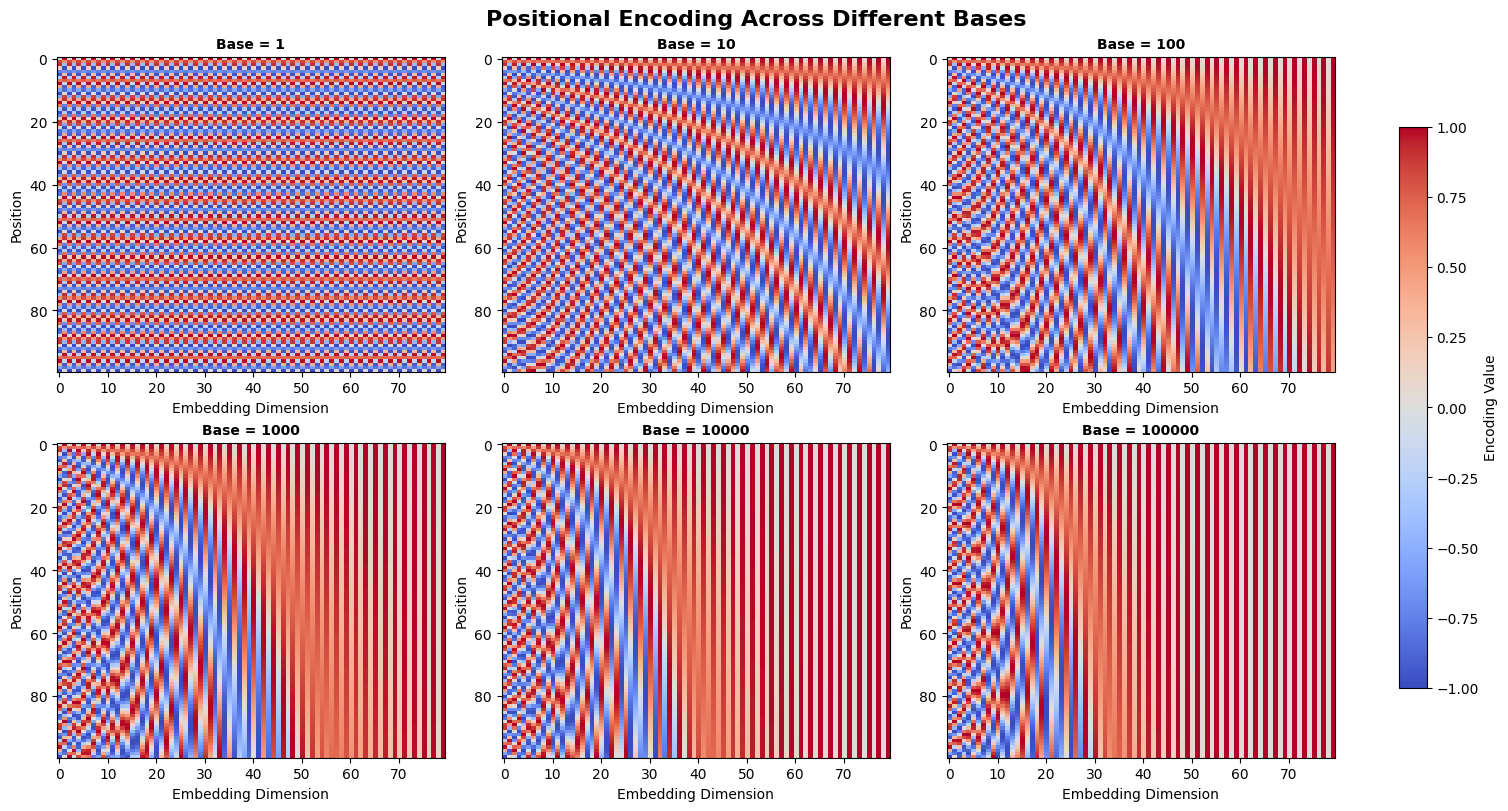

In [16]:
def visualize_positional_encoding_bases(
  max_seq_len: int,
  d_model:int,
  bases:List[int],
  save:bool = False
  )->None:

  fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    layout="constrained"
  )

  fig.suptitle(f"Positional Encoding Across Different Bases", fontsize= 16, fontweight="bold")

  for ax, base in zip(axes.flat, bases):
    pe_matrix = positional_encoding_variant_base(
      max_seq_len,
      d_model,
      base
    )

    im = ax.imshow(
      pe_matrix,
      cmap='coolwarm',
      aspect='auto',
      vmin=-1,
      vmax=1
    )

    ax.set_title(f"Base = {base}", fontsize= 10, fontweight="bold")
    ax.set_xlabel("Embedding Dimension")
    ax.set_ylabel("Position")

  # One shared colorbar for the whole figure
  # Colorbar on the RIGHT side
  fig.colorbar(
    im,
    ax=axes,
    shrink=0.8,
    location="right",
    label="Encoding Value"
  )

  if save:
    plt.savefig(
        "/kaggle/working/positional_encoding_bases_heatmaps.png",
        dpi=100,
        bbox_inches="tight"
    )

  plt.show()


# Example
bases = [1, 10, 100, 1_000, 10_000, 100_000]

visualize_positional_encoding_bases(
  max_seq_len=100,
  d_model=80,
  bases=bases,
  save=True
)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Thanks & Upvote ❤️</div>